<a href="https://colab.research.google.com/github/asheldrick-research/Wide-Binaries-analysis/blob/main/ECSM_Late_Time_Consistency_Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM Late-Time Consistency Test

This notebook implements a late-time consistency test for the Emergent Condensate Superfluid Medium (ECSM) framework.

The test proceeds in three stages:

1. Adopt a canonical supernova-defined ECSM geometry shape
2. Anchor the absolute propagation scale using BAO
3. Predict the late-time growth observable $f\sigma_8(z)$ and compare to RSD data

This notebook is intended as a clean, reproducible companion to the ECSM framework paper.

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import chi2 as chi2dist

print("✅ Imports loaded")
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

✅ Imports loaded
NumPy: 2.0.2
Pandas: 2.2.2


## 1. Data paths

Set the paths to the required datasets. These may point either to Google Drive or to repository-local files.

In [2]:
# --- Edit these paths as needed ---

USE_DRIVE = True

if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')

    ROOT = "/content/drive/MyDrive"
else:
    ROOT = "./data"

RSD_PATH = os.path.join(ROOT, "rsd_fs8_data.csv")

# Optional: include these if you want BAO files loaded in this notebook
BEUTLER_RES = os.path.join(ROOT, "BAO_BEUTLER_results_dM_Hz.txt")
ROSS_RES    = os.path.join(ROOT, "BAO_ROSS_results_dM_Hz.txt")

OUTPUT_DIR = "./outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("✅ ROOT =", ROOT)
print("✅ OUTPUT_DIR =", OUTPUT_DIR)

Mounted at /content/drive
✅ ROOT = /content/drive/MyDrive
✅ OUTPUT_DIR = ./outputs


## 2. Canonical ECSM geometry

We use the canonical S1 geometry shape adopted from the ECSM supernova analysis.

In [3]:
c_kms = 299792.458  # km/s

def d_of_z_S1(z, kappa0, dchi, p):
    """
    ECSM S1 distance-shape mapping:
      d(z) = dchi * [ (1+z)^(-1/kappa0) - 1 ]^(1/p)
    """
    z = np.asarray(z, dtype=float)
    onepz = 1.0 + z
    out = np.full_like(z, np.nan, dtype=float)

    term = np.power(onepz, -1.0 / kappa0) - 1.0
    good = (term > 0) & np.isfinite(term) & (dchi > 0) & (p > 0) & (kappa0 != 0)
    out[good] = dchi * np.power(term[good], 1.0 / p)

    return out

def dd_dz_S1(z, kappa0, dchi, p):
    """
    Analytic derivative of d(z).
    """
    z = np.asarray(z, dtype=float)
    onepz = 1.0 + z
    out = np.full_like(z, np.nan, dtype=float)

    A = np.power(onepz, -1.0 / kappa0) - 1.0
    dA = (-1.0 / kappa0) * np.power(onepz, -1.0 / kappa0 - 1.0)

    good = (A > 0) & np.isfinite(A) & np.isfinite(dA) & (dchi > 0) & (p > 0) & (kappa0 != 0)
    out[good] = dchi * (1.0 / p) * np.power(A[good], 1.0 / p - 1.0) * dA[good]

    return out

def H_of_z_from_S1(z, S, kappa0, dchi, p):
    """
    Effective H(z) derived from the ECSM S1 geometry:
      D_M(z) = S * d(z)
      H(z)   = c / dD_M/dz
    """
    z = np.asarray(z, dtype=float)
    ddz = dd_dz_S1(z, kappa0, dchi, p)
    H = c_kms / (S * ddz)
    H[(~np.isfinite(H)) | (H <= 0)] = np.nan
    return H

print("✅ Geometry functions loaded")

✅ Geometry functions loaded


## 3. Canonical SN shape parameters

These are the fixed ECSM shape parameters inferred from the supernova fit.

In [4]:
best = {
    "kappa0": -4.692887029288703,
    "dchi":   0.04351665070924418,
    "p":      0.9949367088607595
}

kappa0 = float(best["kappa0"])
dchi   = float(best["dchi"])
p_shape = float(best["p"])

print("✅ Canonical SN shape loaded")
print(f"kappa0 = {kappa0}")
print(f"dchi   = {dchi}")
print(f"p      = {p_shape}")

✅ Canonical SN shape loaded
kappa0 = -4.692887029288703
dchi   = 0.04351665070924418
p      = 0.9949367088607595


## 4. BAO anchor

For the canonical late-time bootstrap test, we use the previously established BAO anchor.

In [5]:
# Canonical BAO anchor recovered from the working ECSM BAO workflow
S_bao = 1764647.2966058985

print("✅ Canonical BAO anchor loaded")
print(f"S_bao = {S_bao:.10f}")

✅ Canonical BAO anchor loaded
S_bao = 1764647.2966058985


## 5. ECSM growth solver

This solver evolves the linear growth function using the ECSM-derived effective geometry.

In [6]:
def growth_solve_minimal(z_eval, S, kappa0, dchi, p, Om0=0.32, z_init=30.0, nsteps=12000, z_end=1e-5):
    z_eval = np.asarray(z_eval, dtype=np.float64)

    zmax = max(z_init, float(np.max(z_eval)) + 1.0)
    z_end = min(z_end, 0.1 * np.min(z_eval)) if np.min(z_eval) > 0 else z_end
    z_end = max(z_end, 1e-8)

    z_grid = np.linspace(zmax, z_end, nsteps)
    H_grid = H_of_z_from_S1(z_grid, S, kappa0, dchi, p)

    if not np.isfinite(H_grid).all():
        bad = np.where(~np.isfinite(H_grid))[0]
        raise ValueError(f"H(z) non-finite at {bad.size}/{len(z_grid)} points; first bad z={z_grid[bad[0]]:.4g}")

    H0 = H_grid[-1]
    E = H_grid / H0

    lnH = np.log(H_grid)
    dlnH_dz = np.gradient(lnH, z_grid)

    # Matter-dominated initial conditions: D ~ a, D' = -a^2
    a0 = 1.0 / (1.0 + zmax)
    D0 = a0
    Dp0 = -a0 * a0

    y = np.zeros((nsteps, 2), dtype=np.float64)
    y[0] = [D0, Dp0]

    def rhs(i, z, yv):
        D, Dp = yv
        A = dlnH_dz[i] - 1.0 / (1.0 + z)
        B = 1.5 * Om0 * (1.0 + z) / (E[i] ** 2)
        return np.array([Dp, -A * Dp - B * D], dtype=np.float64)

    for i in range(nsteps - 1):
        z = z_grid[i]
        h = z_grid[i + 1] - z_grid[i]
        k1 = rhs(i, z, y[i])
        k2 = rhs(i, z + 0.5 * h, y[i] + 0.5 * h * k1)
        k3 = rhs(i, z + 0.5 * h, y[i] + 0.5 * h * k2)
        k4 = rhs(i + 1, z + h, y[i] + h * k3)
        y[i + 1] = y[i] + (h / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

    D_grid = y[:, 0]
    Dp_grid = y[:, 1]

    # Normalize at z_end
    Dnorm = D_grid[-1]
    D_grid = D_grid / Dnorm
    Dp_grid = Dp_grid / Dnorm

    D_eval = np.interp(z_eval, z_grid[::-1], D_grid[::-1])
    Dp_eval = np.interp(z_eval, z_grid[::-1], Dp_grid[::-1])

    f_eval = -(1.0 + z_eval) * (Dp_eval / D_eval)
    return f_eval, D_eval

def solve_D_f(z, S, kappa0, dchi, p, Om0=0.32):
    return growth_solve_minimal(z, S, kappa0, dchi, p, Om0=Om0)

print("✅ Growth solver loaded")

✅ Growth solver loaded


## 6. Load RSD data

We now load the observed $f\sigma_8(z)$ dataset.

In [7]:
rsd = pd.read_csv(RSD_PATH)
rsd = rsd.rename(columns={c: c.strip() for c in rsd.columns})

colz = [c for c in rsd.columns if c.lower() in ["z", "zeff", "z_eff"]][0]
coly = [c for c in rsd.columns if c.lower() in ["fs8", "f*s8", "f*sigma8", "f_sigma8"]][0]
cole = [c for c in rsd.columns if c.lower() in ["err", "sigma", "error", "fs8_err"]][0]

z_rsd = rsd[colz].to_numpy(float)
fs8_obs = rsd[coly].to_numpy(float)
fs8_err = rsd[cole].to_numpy(float)

print(f"✅ Loaded RSD: N={len(z_rsd)} columns=({colz}, {coly}, {cole})")
rsd.head()

✅ Loaded RSD: N=15 columns=(z, fs8, err)


,z,fs8,err
0,0.020,0.428,0.046
1,0.067,0.423,0.055
2,0.100,0.370,0.130
3,0.150,0.490,0.150
4,0.170,0.510,0.060


## 7. BAO→RSD canonical bootstrap test

Using the canonical ECSM geometry shape and BAO anchor, we predict the growth history and fit the overall normalization.

In [13]:


def fit_sigma8(fs8_obs, fs8_err, X):
    fs8_obs = np.asarray(fs8_obs, float)
    fs8_err = np.asarray(fs8_err, float)
    X = np.asarray(X, float)

    w = 1.0 / (fs8_err ** 2)
    m = np.isfinite(fs8_obs) & np.isfinite(fs8_err) & np.isfinite(X) & (fs8_err > 0) & (X != 0)

    if m.sum() == 0:
        return np.nan

    return np.sum(w[m] * X[m] * fs8_obs[m]) / np.sum(w[m] * X[m] * X[m])

Om0 = 0.320

# Solve ECSM growth
f_th, D_th = solve_D_f(z_rsd, S_bao, kappa0, dchi, p_shape, Om0=Om0)
fD_th = f_th * D_th

# Fit normalization
sigma8_0 = fit_sigma8(fs8_obs, fs8_err, fD_th)

# Enforce positive normalization convention for presentation
if sigma8_0 < 0:
    sigma8_0 = -sigma8_0
    fD_th = -fD_th

fs8_th = sigma8_0 * fD_th
pull = (fs8_obs - fs8_th) / fs8_err
chi2 = np.sum(pull[np.isfinite(pull)] ** 2)
dof = len(z_rsd) - 1
pval = float(chi2dist.sf(chi2, dof))

rsd_fit = pd.DataFrame({
    "z": z_rsd,
    "fs8_obs": fs8_obs,
    "fs8_err": fs8_err,
    "fD_th": fD_th,
    "sigma8_0": sigma8_0,
    "fs8_th": fs8_th,
    "pull": pull
}).sort_values("z").reset_index(drop=True)

print("\n=== ECSM BAO→RSD (canonical bootstrap) ===")
print(f"SN shape: kappa0={kappa0:.5f}, dchi={dchi:.6g}, p={p_shape:.6g}")
print(f"BAO anchor S_bao={S_bao:.6g}")
print(f"Ωm fixed={Om0:.3f}")
print(f"Best σ8_0 = {sigma8_0:.6f}")
print(f"chi2 = {chi2:.6f}   dof = {dof}   chi2/dof = {chi2/dof:.6f}   p = {pval}")
print(f"RMS pull = {np.sqrt(np.nanmean(pull**2)):.6f}   Max |pull| = {np.nanmax(np.abs(pull)):.6f}")

rsd_fit


=== ECSM BAO→RSD (canonical bootstrap) ===
SN shape: kappa0=-4.69289, dchi=0.0435167, p=0.994937
BAO anchor S_bao=1.76465e+06
Ωm fixed=0.320
Best σ8_0 = 0.182816
chi2 = 13.180913   dof = 14   chi2/dof = 0.941494   p = 0.5123304345365834
RMS pull = 0.937405   Max |pull| = 1.974551


,z,fs8_obs,fs8_err,fD_th,sigma8_0,fs8_th,pull
0,0.020,0.428,0.046,1.881931,0.182816,0.344047,1.825074
1,0.067,0.423,0.055,1.971735,0.182816,0.360464,1.137016
2,0.100,0.370,0.130,2.028891,0.182816,0.370913,-0.007024
3,0.150,0.490,0.150,2.110476,0.182816,0.385828,0.694479
4,0.170,0.510,0.060,2.141649,0.182816,0.391527,1.974551
5,0.320,0.384,0.095,2.350490,0.182816,0.429706,-0.481120
6,0.380,0.440,0.060,2.421590,0.182816,0.442705,-0.045078
7,0.440,0.413,0.080,2.485338,0.182816,0.454359,-0.516984
8,0.510,0.460,0.050,2.550160,0.182816,0.466209,-0.124186
9,0.570,0.444,0.038,2.597326,0.182816,0.474832,-0.811365


The fitted normalization parameter should be interpreted as the internal amplitude required by the ECSM bootstrap pipeline under the adopted geometry and BAO anchor. The primary observable test is the agreement of the predicted and observed $f\sigma_8(z)$ values, summarized by the fit statistics above.

## 8. Plot the ECSM late-time growth fit

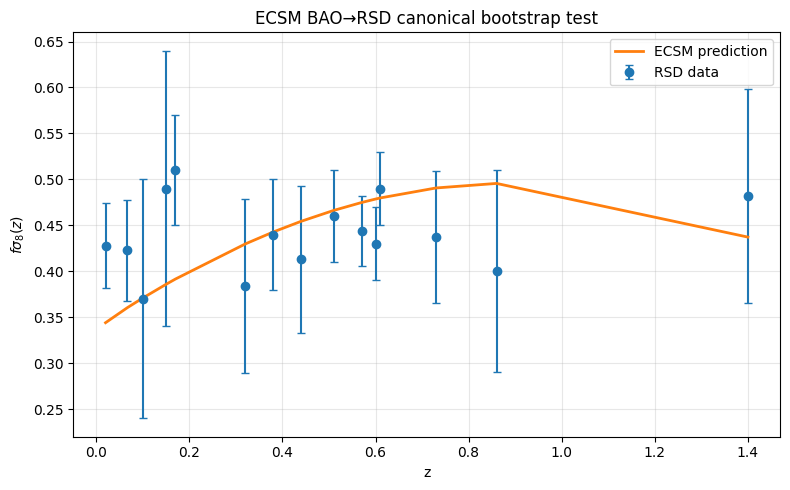

✅ Saved plot to: ./outputs/ecsm_bao_rsd_fit.png


In [14]:
plt.figure(figsize=(8, 5))
plt.errorbar(rsd_fit["z"], rsd_fit["fs8_obs"], yerr=rsd_fit["fs8_err"],
             fmt='o', capsize=3, label="RSD data")
plt.plot(rsd_fit["z"], rsd_fit["fs8_th"], lw=2, label="ECSM prediction")

plt.xlabel("z")
plt.ylabel(r"$f\sigma_8(z)$")
plt.title("ECSM BAO→RSD canonical bootstrap test")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plot_path = os.path.join(OUTPUT_DIR, "ecsm_bao_rsd_fit.png")
plt.savefig(plot_path, dpi=200)
plt.show()

print("✅ Saved plot to:", plot_path)

## 9. Pull diagnostics

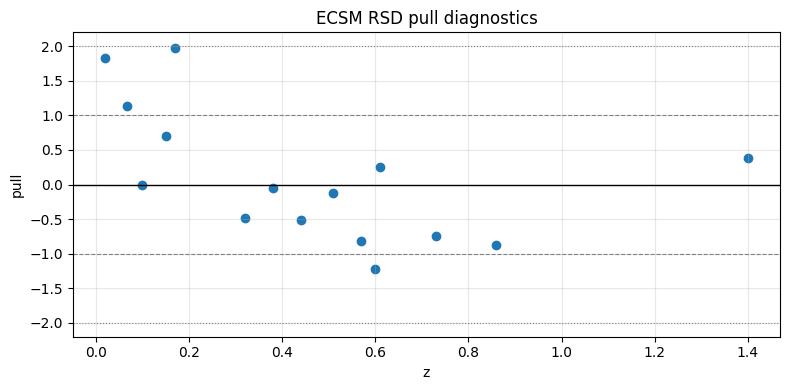

✅ Saved pull plot to: ./outputs/ecsm_bao_rsd_pulls.png


In [15]:
plt.figure(figsize=(8, 4))
plt.axhline(0.0, color='k', lw=1)
plt.axhline(1.0, color='gray', lw=0.8, ls='--')
plt.axhline(-1.0, color='gray', lw=0.8, ls='--')
plt.axhline(2.0, color='gray', lw=0.8, ls=':')
plt.axhline(-2.0, color='gray', lw=0.8, ls=':')

plt.scatter(rsd_fit["z"], rsd_fit["pull"])
plt.xlabel("z")
plt.ylabel("pull")
plt.title("ECSM RSD pull diagnostics")
plt.grid(alpha=0.3)
plt.tight_layout()

pull_path = os.path.join(OUTPUT_DIR, "ecsm_bao_rsd_pulls.png")
plt.savefig(pull_path, dpi=200)
plt.show()

print("✅ Saved pull plot to:", pull_path)

## 10. Export results

In [16]:
csv_path = os.path.join(OUTPUT_DIR, "rsd_fit.csv")
json_path = os.path.join(OUTPUT_DIR, "summary.json")

rsd_fit.to_csv(csv_path, index=False)

summary = {
    "kappa0": kappa0,
    "dchi": dchi,
    "p_shape": p_shape,
    "S_bao": S_bao,
    "Om0": Om0,
    "sigma8_0": float(sigma8_0),
    "chi2": float(chi2),
    "dof": int(dof),
    "chi2_dof": float(chi2 / dof),
    "p_value": float(pval),
    "rms_pull": float(np.sqrt(np.nanmean(pull**2))),
    "max_abs_pull": float(np.nanmax(np.abs(pull)))
}

with open(json_path, "w") as f:
    json.dump(summary, f, indent=2)

print("✅ Saved CSV:", csv_path)
print("✅ Saved summary:", json_path)
summary

✅ Saved CSV: ./outputs/rsd_fit.csv
✅ Saved summary: ./outputs/summary.json


{'kappa0': -4.692887029288703,
 'dchi': 0.04351665070924418,
 'p_shape': 0.9949367088607595,
 'S_bao': 1764647.2966058985,
 'Om0': 0.32,
 'sigma8_0': 0.18281568156949912,
 'chi2': 13.180913048619836,
 'dof': 14,
 'chi2_dof': 0.9414937891871311,
 'p_value': 0.5123304345365834,
 'rms_pull': 0.9374046813274701,
 'max_abs_pull': 1.9745509851574814}

## 11. Summary

This notebook implements a clean late-time ECSM bootstrap test using:

- a canonical supernova-defined ECSM geometry shape,
- a fixed BAO propagation-scale anchor,
- and RSD growth data.

The resulting fit statistics and plots provide a reproducible late-time consistency test that can be linked directly from the ECSM paper and project repository.